# Análise de Desempenho - Multiplicação de Matrizes

Este notebook analisa os resultados das execuções de multiplicação de matrizes:
- Linear (single-core)
- Paralela Local (multi-core)
- Paralela Distribuída (multi-core em múltiplos backends)

In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

# Configurar estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 1. Carregar Dados

In [6]:
# Carregar estatísticas
stats_file = Path('results/stats.json')

if not stats_file.exists():
    print("Erro: Arquivo stats.json não encontrado!")
    print("Execute os scripts de multiplicação primeiro.")
else:
    with open(stats_file, 'r') as f:
        stats = json.load(f)
    
    print(f"Total de execuções registradas: {len(stats)}")
    print("\nResumo dos dados:")
    for i, stat in enumerate(stats):
        for mode, data in stat.items():
            print(f"  {i+1}. {mode}: {data.get('time_seconds', 0):.4f}s com {data.get('num_cores', 1)} núcleos")

Total de execuções registradas: 3

Resumo dos dados:
  1. Parallel_Distributed: 4.8907s com distributed núcleos
  2. Linear: 0.2806s com 1 núcleos
  3. Parallel_Local: 0.1669s com 8 núcleos


## 2. Organizar Dados para Análise

In [7]:
# Organizar dados
results = {}

for stat in stats:
    for mode, data in stat.items():
        if mode not in results:
            results[mode] = data

# Criar DataFrame para análise
df_data = []
for mode, data in results.items():
    df_data.append({
        'Modo': mode,
        'Tempo (s)': data.get('time_seconds', 0),
        'Núcleos': data.get('num_cores', 1) if isinstance(data.get('num_cores'), int) else 'N/A',
        'Block Size': data.get('block_size', 0)
    })

df = pd.DataFrame(df_data)
print("\nDataFrame de Resultados:")
display(df)


DataFrame de Resultados:


,Modo,Tempo (s),Núcleos,Block Size
0,Parallel_Distributed,4.890731,N/A,64
1,Linear,0.280568,1,64
2,Parallel_Local,0.166920,8,64


## 3. Gráfico de Tempo de Execução

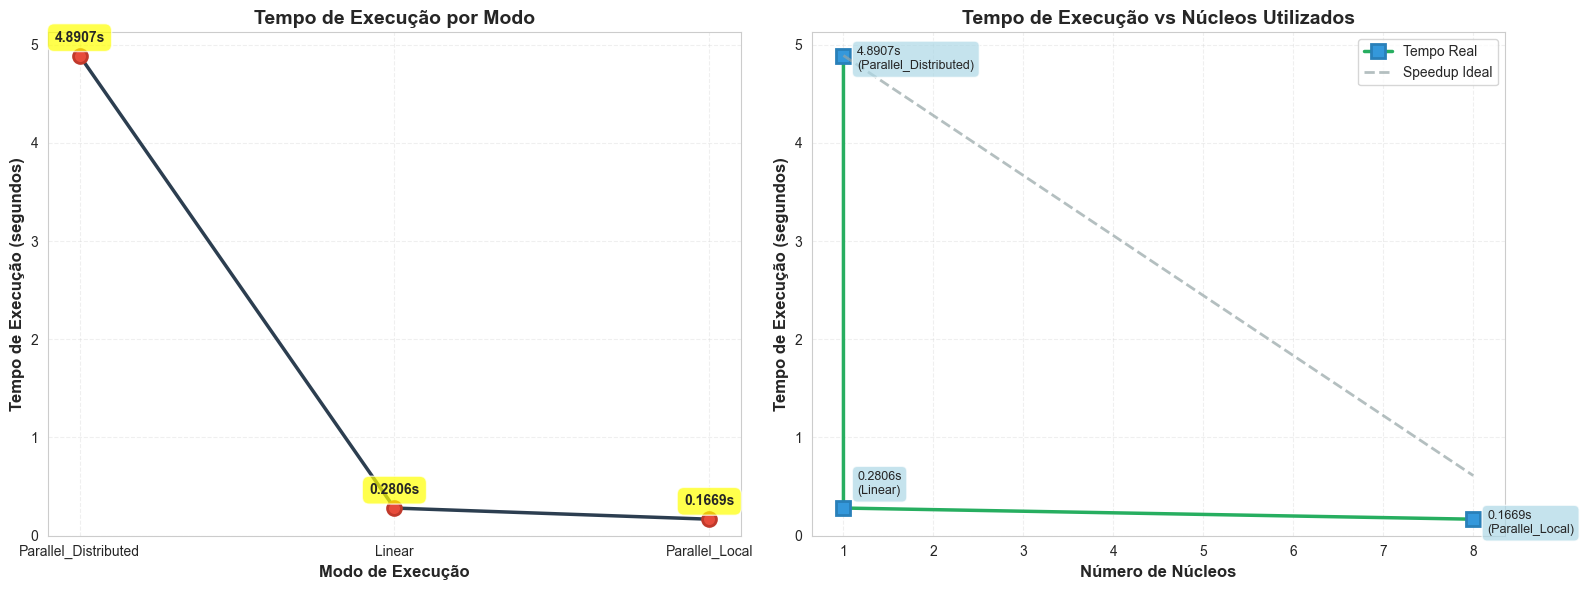

✓ Gráfico salvo em: results/execution_time_comparison.png


In [8]:
# Gráfico de linha comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

modes = [item['Modo'] for item in df_data]
times = [item['Tempo (s)'] for item in df_data]
cores_list = [item['Núcleos'] if isinstance(item['Núcleos'], int) else 1 for item in df_data]

# Gráfico 1: Tempo de Execução
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
ax1.plot(modes, times, marker='o', linewidth=2.5, markersize=10, 
         color='#2c3e50', markerfacecolor='#e74c3c', markeredgewidth=2, 
         markeredgecolor='#c0392b')

# Adicionar valores nos pontos
for i, (mode, time) in enumerate(zip(modes, times)):
    ax1.annotate(f'{time:.4f}s', 
                xy=(i, time), 
                xytext=(0, 10),
                textcoords='offset points',
                ha='center',
                fontsize=10,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

ax1.set_xlabel('Modo de Execução', fontsize=12, fontweight='bold')
ax1.set_ylabel('Tempo de Execução (segundos)', fontsize=12, fontweight='bold')
ax1.set_title('Tempo de Execução por Modo', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_ylim(bottom=0)

# Gráfico 2: Tempo vs Núcleos
# Ordenar por número de núcleos
sorted_data = sorted(zip(cores_list, times, modes), key=lambda x: x[0])
sorted_cores, sorted_times, sorted_modes = zip(*sorted_data)

ax2.plot(sorted_cores, sorted_times, marker='s', linewidth=2.5, markersize=10,
         color='#27ae60', markerfacecolor='#3498db', markeredgewidth=2,
         markeredgecolor='#2980b9', label='Tempo Real')

# Linha ideal (inversamente proporcional)
if len(sorted_times) > 0:
    base_time = sorted_times[0]
    ideal_times = [base_time / c for c in sorted_cores]
    ax2.plot(sorted_cores, ideal_times, '--', linewidth=2, color='#95a5a6',
             label='Speedup Ideal', alpha=0.7)

# Adicionar valores nos pontos
for i, (core, time, mode) in enumerate(zip(sorted_cores, sorted_times, sorted_modes)):
    ax2.annotate(f'{time:.4f}s\n({mode})', 
                xy=(core, time), 
                xytext=(10, -10 if i % 2 == 0 else 10),
                textcoords='offset points',
                ha='left',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.7))

ax2.set_xlabel('Número de Núcleos', fontsize=12, fontweight='bold')
ax2.set_ylabel('Tempo de Execução (segundos)', fontsize=12, fontweight='bold')
ax2.set_title('Tempo de Execução vs Núcleos Utilizados', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(loc='best')
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('results/execution_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico salvo em: results/execution_time_comparison.png")

## 4. Análise de Speedup

In [9]:
# Calcular speedup (usando Linear como baseline)
if 'Linear' in results:
    base_time = results['Linear']['time_seconds']
    
    speedup_data = []
    
    for mode, data in results.items():
        if mode != 'Linear':
            time = data['time_seconds']
            cores = data.get('num_cores', 1)
            
            if isinstance(cores, int):
                speedup = base_time / time if time > 0 else 0
                efficiency = (speedup / cores) * 100 if cores > 0 else 0
                
                # Classificar speedup
                if speedup < cores * 0.9:
                    classification = "Sublinear"
                elif speedup <= cores * 1.1:
                    classification = "Linear"
                else:
                    classification = "Superlinear"
                
                speedup_data.append({
                    'Modo': mode,
                    'Tempo Base (s)': base_time,
                    'Tempo Paralelo (s)': time,
                    'Núcleos': cores,
                    'Speedup': speedup,
                    'Speedup Ideal': cores,
                    'Eficiência (%)': efficiency,
                    'Classificação': classification
                })
    
    df_speedup = pd.DataFrame(speedup_data)
    print("\nAnálise de Speedup:")
    print("=" * 80)
    display(df_speedup)
    
    # Interpretação
    print("\nInterpretação:")
    print("=" * 80)
    for _, row in df_speedup.iterrows():
        print(f"\n{row['Modo']}:")
        print(f"  - Speedup: {row['Speedup']:.2f}x (ideal: {row['Speedup Ideal']}x)")
        print(f"  - Eficiência: {row['Eficiência (%)']:.2f}%")
        print(f"  - Classificação: {row['Classificação']}")
        
        if row['Classificação'] == 'Sublinear':
            print("  ⚠ Speedup abaixo do ideal - possíveis overhead de comunicação/sincronização")
        elif row['Classificação'] == 'Linear':
            print("  ✓ Speedup próximo ao ideal - paralelização eficiente")
        else:
            print("  ★ Speedup superlinear - ganho excepcional (cache, otimizações)")
else:
    print("Erro: Não há dados de execução Linear para calcular speedup")


Análise de Speedup:


,Modo,Tempo Base (s),Tempo Paralelo (s),Núcleos,Speedup,Speedup Ideal,Eficiência (%),Classificação
0,Parallel_Local,0.280568,0.16692,8,1.680851,8,21.010632,Sublinear



Interpretação:

Parallel_Local:
  - Speedup: 1.68x (ideal: 8x)
  - Eficiência: 21.01%
  - Classificação: Sublinear
  ⚠ Speedup abaixo do ideal - possíveis overhead de comunicação/sincronização


## 5. Gráfico de Speedup

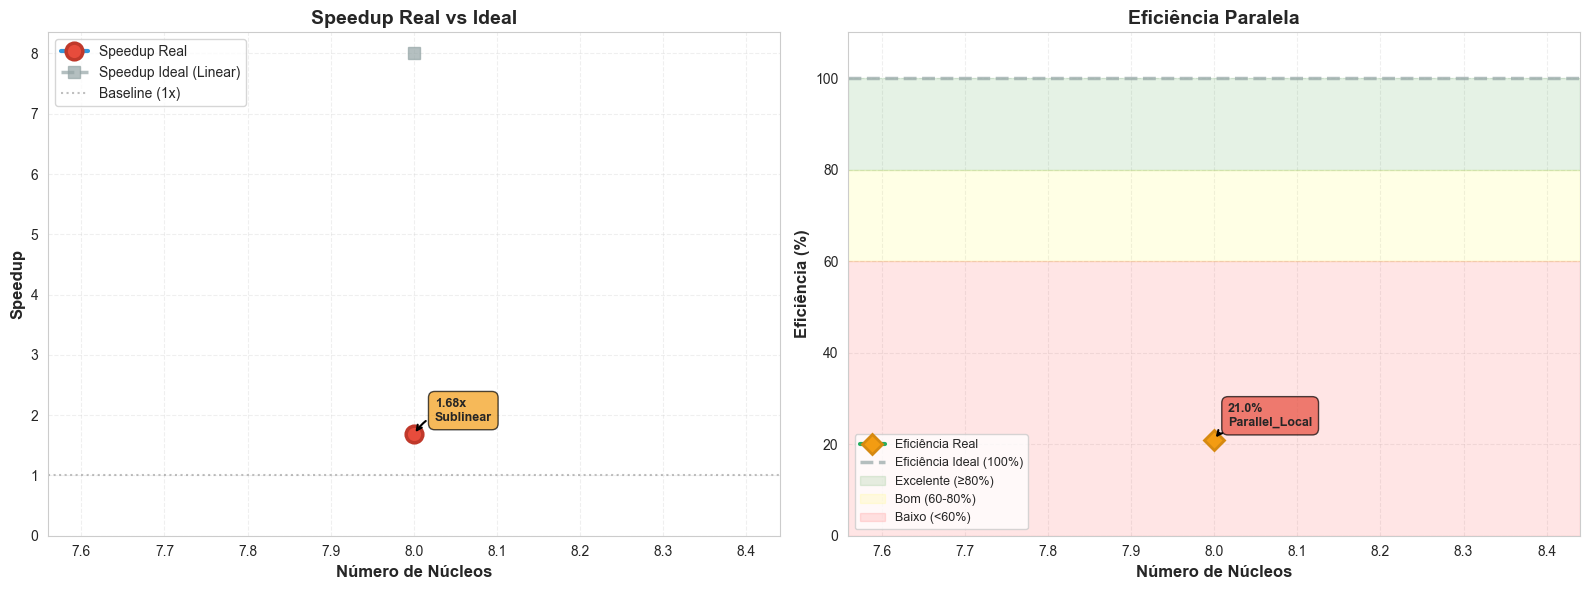

✓ Gráfico salvo em: results/speedup_analysis.png


In [10]:
if len(speedup_data) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Gráfico 1: Speedup Real vs Ideal (Linha)
    modes = [item['Modo'] for item in speedup_data]
    cores = [item['Núcleos'] for item in speedup_data]
    speedups = [item['Speedup'] for item in speedup_data]
    ideal = [item['Speedup Ideal'] for item in speedup_data]
    
    # Ordenar por número de núcleos para melhor visualização
    sorted_data = sorted(zip(cores, speedups, ideal, modes), key=lambda x: x[0])
    sorted_cores, sorted_speedups, sorted_ideal, sorted_modes = zip(*sorted_data)
    
    # Linha de speedup real
    ax1.plot(sorted_cores, sorted_speedups, marker='o', linewidth=3, markersize=12,
             color='#3498db', markerfacecolor='#e74c3c', markeredgewidth=2.5,
             markeredgecolor='#c0392b', label='Speedup Real', zorder=3)
    
    # Linha de speedup ideal
    ax1.plot(sorted_cores, sorted_ideal, '--', linewidth=2.5, color='#95a5a6',
             marker='s', markersize=8, label='Speedup Ideal (Linear)', 
             alpha=0.7, zorder=2)
    
    # Linha de referência (speedup = 1)
    ax1.axhline(y=1, color='gray', linestyle=':', alpha=0.5, linewidth=1.5, 
                label='Baseline (1x)', zorder=1)
    
    # Adicionar valores e classificações nos pontos
    for i, (core, speedup, mode) in enumerate(zip(sorted_cores, sorted_speedups, sorted_modes)):
        classification = speedup_data[i]['Classificação']
        color_class = '#2ecc71' if classification == 'Linear' else \
                     '#f39c12' if classification == 'Sublinear' else '#9b59b6'
        
        ax1.annotate(f'{speedup:.2f}x\n{classification}', 
                    xy=(core, speedup), 
                    xytext=(15, 10 if i % 2 == 0 else -25),
                    textcoords='offset points',
                    ha='left',
                    fontsize=9,
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.5', 
                             facecolor=color_class, alpha=0.7, edgecolor='black'),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3',
                                   color='black', lw=1.5))
    
    ax1.set_xlabel('Número de Núcleos', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Speedup', fontsize=12, fontweight='bold')
    ax1.set_title('Speedup Real vs Ideal', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_ylim(bottom=0)
    
    # Gráfico 2: Eficiência (Linha)
    efficiencies = [item['Eficiência (%)'] for item in speedup_data]
    sorted_effs = [e for _, e in sorted(zip(cores, efficiencies), key=lambda x: x[0])]
    
    # Linha de eficiência
    line_eff = ax2.plot(sorted_cores, sorted_effs, marker='D', linewidth=3, markersize=10,
                        color='#27ae60', markerfacecolor='#f39c12', markeredgewidth=2,
                        markeredgecolor='#d68910', label='Eficiência Real', zorder=3)
    
    # Linha de eficiência ideal (100%)
    ax2.axhline(y=100, color='#95a5a6', linestyle='--', linewidth=2.5, 
                label='Eficiência Ideal (100%)', alpha=0.7, zorder=2)
    
    # Zonas de eficiência
    ax2.axhspan(80, 100, alpha=0.1, color='green', label='Excelente (≥80%)')
    ax2.axhspan(60, 80, alpha=0.1, color='yellow', label='Bom (60-80%)')
    ax2.axhspan(0, 60, alpha=0.1, color='red', label='Baixo (<60%)')
    
    # Adicionar valores nos pontos
    for i, (core, eff, mode) in enumerate(zip(sorted_cores, sorted_effs, sorted_modes)):
        color_eff = '#2ecc71' if eff >= 80 else '#f39c12' if eff >= 60 else '#e74c3c'
        
        ax2.annotate(f'{eff:.1f}%\n{mode}', 
                    xy=(core, eff), 
                    xytext=(10, 10 if i % 2 == 0 else -25),
                    textcoords='offset points',
                    ha='left',
                    fontsize=9,
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.5', 
                             facecolor=color_eff, alpha=0.7, edgecolor='black'),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3',
                                   color='black', lw=1.5))
    
    ax2.set_xlabel('Número de Núcleos', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Eficiência (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Eficiência Paralela', fontsize=14, fontweight='bold')
    ax2.legend(loc='best', fontsize=9)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_ylim(0, 110)
    
    plt.tight_layout()
    plt.savefig('results/speedup_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Gráfico salvo em: results/speedup_analysis.png")

## 5.1. Gráfico Comparativo Completo

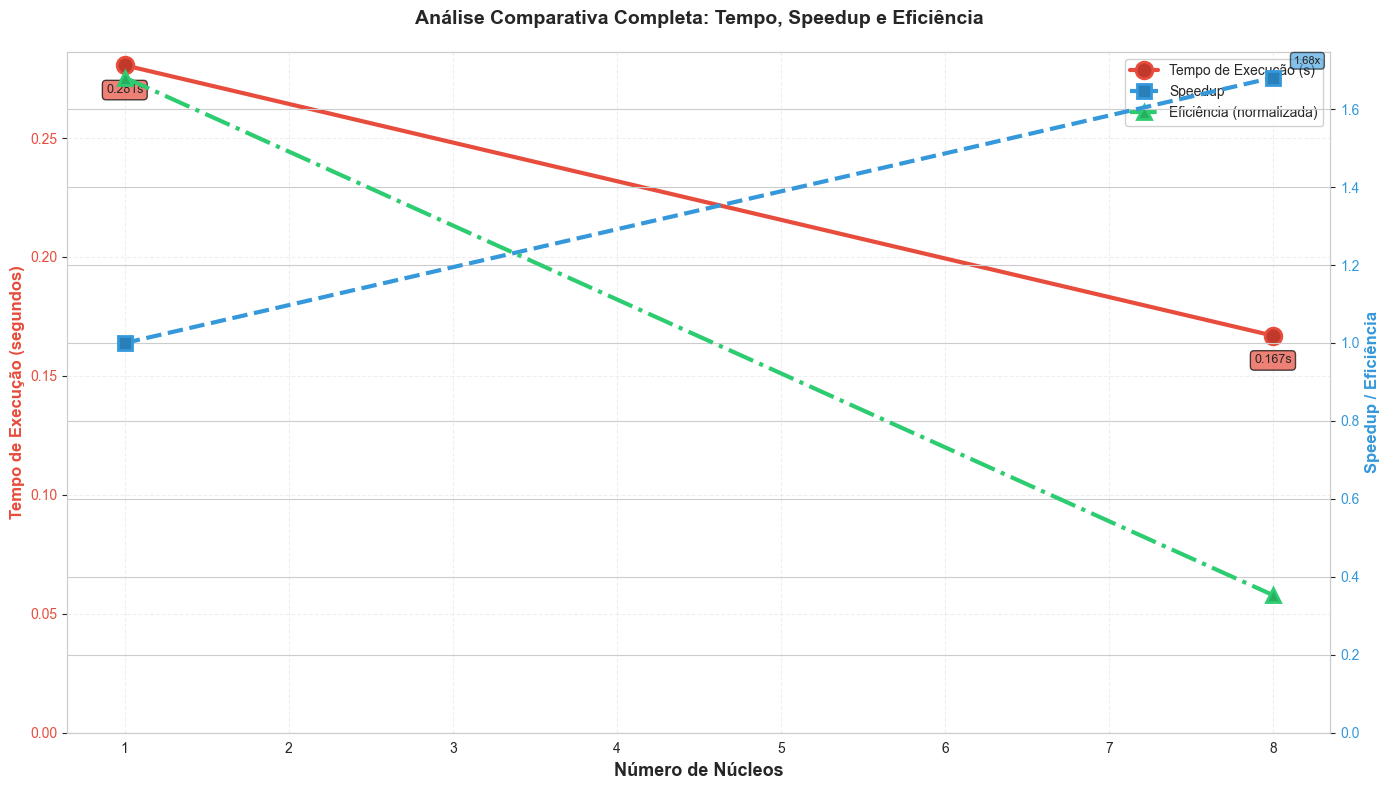

✓ Gráfico salvo em: results/complete_analysis.png


In [11]:
if len(speedup_data) > 0:
    # Criar gráfico com múltiplas linhas mostrando todas as métricas
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Preparar dados
    modes = ['Linear'] + [item['Modo'] for item in speedup_data]
    all_cores = [1] + [item['Núcleos'] for item in speedup_data]
    all_times = [results['Linear']['time_seconds']] + \
                [item['Tempo Paralelo (s)'] for item in speedup_data]
    all_speedups = [1.0] + [item['Speedup'] for item in speedup_data]
    all_effs = [100.0] + [item['Eficiência (%)'] for item in speedup_data]
    
    # Criar eixo secundário
    ax2 = ax.twinx()
    
    # Plotar tempo de execução (eixo primário)
    line1 = ax.plot(all_cores, all_times, marker='o', linewidth=3, markersize=12,
                    color='#e74c3c', markerfacecolor='#c0392b', markeredgewidth=2,
                    label='Tempo de Execução (s)', zorder=3)
    
    # Plotar speedup (eixo secundário)
    line2 = ax2.plot(all_cores, all_speedups, marker='s', linewidth=3, markersize=10,
                     color='#3498db', markerfacecolor='#2980b9', markeredgewidth=2,
                     label='Speedup', linestyle='--', zorder=2)
    
    # Plotar eficiência normalizada (0-1 scale no eixo secundário)
    eff_normalized = [e/100 * max(all_speedups) for e in all_effs]
    line3 = ax2.plot(all_cores, eff_normalized, marker='^', linewidth=3, markersize=10,
                     color='#2ecc71', markerfacecolor='#27ae60', markeredgewidth=2,
                     label='Eficiência (normalizada)', linestyle='-.', zorder=2)
    
    # Adicionar anotações
    for i, (cores, time, speedup, mode) in enumerate(zip(all_cores, all_times, all_speedups, modes)):
        # Anotação de tempo
        ax.annotate(f'{time:.3f}s', 
                   xy=(cores, time), 
                   xytext=(0, -20),
                   textcoords='offset points',
                   ha='center',
                   fontsize=9,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='#e74c3c', 
                            alpha=0.7, edgecolor='black'))
        
        # Anotação de speedup
        if speedup > 1:
            ax2.annotate(f'{speedup:.2f}x', 
                        xy=(cores, speedup), 
                        xytext=(15, 10),
                        textcoords='offset points',
                        ha='left',
                        fontsize=8,
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='#3498db', 
                                 alpha=0.6, edgecolor='black'))
    
    # Configurar eixos
    ax.set_xlabel('Número de Núcleos', fontsize=13, fontweight='bold')
    ax.set_ylabel('Tempo de Execução (segundos)', fontsize=12, fontweight='bold', color='#e74c3c')
    ax2.set_ylabel('Speedup / Eficiência', fontsize=12, fontweight='bold', color='#3498db')
    
    ax.tick_params(axis='y', labelcolor='#e74c3c')
    ax2.tick_params(axis='y', labelcolor='#3498db')
    
    # Título e grade
    ax.set_title('Análise Comparativa Completa: Tempo, Speedup e Eficiência', 
                fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Legendas combinadas
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper right', fontsize=10, framealpha=0.9)
    
    # Configurar limites
    ax.set_ylim(bottom=0)
    ax2.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.savefig('results/complete_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Gráfico salvo em: results/complete_analysis.png")

## 6. Análise de Benchmark (se disponível)

In [12]:
# Verificar se há dados de benchmark
benchmark_available = False
for mode, data in results.items():
    if 'benchmark' in data:
        benchmark_available = True
        break

if benchmark_available:
    print("Benchmark do Sistema")
    print("=" * 80)
    
    for mode, data in results.items():
        if 'benchmark' in data:
            bench = data['benchmark']
            
            print(f"\n{mode}:")
            print("-" * 80)
            
            if 'system_info' in bench:
                sys_info = bench['system_info']
                print(f"Sistema: {sys_info.get('platform', 'N/A')} {sys_info.get('platform_release', '')}")
                print(f"Processador: {sys_info.get('processor', 'N/A')}")
                print(f"Cores: {sys_info.get('cpu_cores', 'N/A')} | Threads: {sys_info.get('cpu_threads', 'N/A')}")
                print(f"RAM: {sys_info.get('ram_total_gb', 'N/A')} GB")
            
            if 'integer_benchmark' in bench:
                int_bench = bench['integer_benchmark']
                print(f"\nOperações Inteiras:")
                print(f"  Tempo: {int_bench.get('time_seconds', 0):.4f}s")
                print(f"  Ops/seg: {int_bench.get('ops_per_second', 0):.2e}")
            
            if 'float_benchmark' in bench:
                float_bench = bench['float_benchmark']
                print(f"\nOperações Ponto Flutuante:")
                print(f"  Tempo: {float_bench.get('time_seconds', 0):.4f}s")
                print(f"  Ops/seg: {float_bench.get('ops_per_second', 0):.2e}")
            
            break  # Mostrar apenas um benchmark
else:
    print("Nenhum dado de benchmark disponível.")
    print("Execute os scripts com --benchmark para incluir dados de benchmark.")

Benchmark do Sistema

Linear:
--------------------------------------------------------------------------------
Sistema: Linux 6.16.3-76061603-generic
Processador: x86_64
Cores: 4 | Threads: 8
RAM: 23.23 GB

Operações Inteiras:
  Tempo: 0.0038s
  Ops/seg: 2.62e+09

Operações Ponto Flutuante:
  Tempo: 0.0399s
  Ops/seg: 2.51e+08


## 7. Metodologia Foster - Aplicação Distribuída

Análise da aplicação distribuída seguindo a Metodologia Foster.

In [13]:
print("ANÁLISE SEGUNDO A METODOLOGIA FOSTER")
print("=" * 80)

print("\n1. DECOMPOSIÇÃO")
print("-" * 80)
print("Estratégia: Decomposição por Dados (Data Parallelism)")
print("\nDescrição:")
print("  - A matriz A é dividida horizontalmente em blocos de linhas")
print("  - Cada servidor recebe um subconjunto de linhas da matriz A")
print("  - A matriz B é replicada completamente para todos os servidores")
print("  - Cada servidor calcula C[i:j] = A[i:j] × B")
print("\nGranularidade:")
print("  - Nível 1: Divisão entre servidores (granularidade grossa)")
print("  - Nível 2: Divisão interna em cada servidor entre núcleos (granularidade média)")
print("  - Nível 3: Block tiling para otimização de cache (granularidade fina)")

print("\n2. COMUNICAÇÃO")
print("-" * 80)
print("Padrão: Master-Worker com comunicação mínima")
print("\nFluxo:")
print("  1. Cliente distribui dados (broadcast de B, scatter de A)")
print("  2. Servidores computam localmente (sem comunicação inter-servidor)")
print("  3. Cliente coleta resultados (gather de C)")
print("\nProtocolo: Pyro5 (Remote Method Invocation)")
print("  - Serialização automática de dados")
print("  - Chamadas síncronas com threads para paralelismo")
print("\nOverhead de Comunicação:")
print("  - Transmissão inicial: O(n²) para matrizes n×n")
print("  - Transmissão final: O(n²/p) por servidor, onde p = número de servidores")
print("  - Sem comunicação durante computação")

print("\n3. AGLOMERAÇÃO")
print("-" * 80)
print("Estratégia: Aglomeração em dois níveis")
print("\nNível 1 - Entre Servidores:")
print("  - Tarefas agrupadas em blocos de linhas contíguas")
print("  - Minimiza overhead de comunicação")
print("  - Balanceamento de carga: linhas distribuídas uniformemente")
print("\nNível 2 - Dentro de Cada Servidor:")
print("  - Uso de shared memory para comunicação entre processos locais")
print("  - Block tiling para maximizar uso de cache")
print("  - Paralelização automática entre núcleos disponíveis")

print("\n4. MAPEAMENTO")
print("-" * 80)
print("Estratégia: Mapeamento estático com balanceamento de carga")
print("\nMapeamento entre Servidores:")
print("  - Distribuição round-robin de blocos de linhas")
print("  - Último servidor recebe linhas remanescentes (se houver)")
print("  - Minimiza desbalanceamento de carga")
print("\nMapeamento Local (dentro de cada servidor):")
print("  - Sistema operacional gerencia alocação de processos em núcleos")
print("  - Shared memory permite acesso eficiente aos dados")
print("  - Numba JIT otimiza código para arquitetura específica")

print("\n" + "=" * 80)

ANÁLISE SEGUNDO A METODOLOGIA FOSTER

1. DECOMPOSIÇÃO
--------------------------------------------------------------------------------
Estratégia: Decomposição por Dados (Data Parallelism)

Descrição:
  - A matriz A é dividida horizontalmente em blocos de linhas
  - Cada servidor recebe um subconjunto de linhas da matriz A
  - A matriz B é replicada completamente para todos os servidores
  - Cada servidor calcula C[i:j] = A[i:j] × B

Granularidade:
  - Nível 1: Divisão entre servidores (granularidade grossa)
  - Nível 2: Divisão interna em cada servidor entre núcleos (granularidade média)
  - Nível 3: Block tiling para otimização de cache (granularidade fina)

2. COMUNICAÇÃO
--------------------------------------------------------------------------------
Padrão: Master-Worker com comunicação mínima

Fluxo:
  1. Cliente distribui dados (broadcast de B, scatter de A)
  2. Servidores computam localmente (sem comunicação inter-servidor)
  3. Cliente coleta resultados (gather de C)

Protoco

## 8. Conclusões

In [14]:
print("CONCLUSÕES DA ANÁLISE")
print("=" * 80)

if len(speedup_data) > 0:
    print("\n1. Desempenho Geral:")
    fastest = min(speedup_data, key=lambda x: x['Tempo Paralelo (s)'])
    print(f"  - Método mais rápido: {fastest['Modo']}")
    print(f"  - Tempo: {fastest['Tempo Paralelo (s)']:.4f}s")
    print(f"  - Ganho: {fastest['Speedup']:.2f}x em relação ao linear")
    
    print("\n2. Eficiência:")
    for item in speedup_data:
        print(f"  - {item['Modo']}: {item['Eficiência (%)']:.2f}%")
    
    print("\n3. Recomendações:")
    best_efficiency = max(speedup_data, key=lambda x: x['Eficiência (%)'])
    if best_efficiency['Eficiência (%)'] >= 80:
        print(f"  ✓ {best_efficiency['Modo']} apresenta excelente eficiência")
    
    for item in speedup_data:
        if item['Eficiência (%)'] < 60:
            print(f"  ⚠ {item['Modo']} pode ser otimizado:")
            print(f"    - Considerar reduzir overhead de comunicação")
            print(f"    - Ajustar tamanho de blocos (block_size)")
            print(f"    - Verificar balanceamento de carga")

print("\n" + "=" * 80)
print("Análise concluída!")
print("Gráficos salvos em: results/")

CONCLUSÕES DA ANÁLISE

1. Desempenho Geral:
  - Método mais rápido: Parallel_Local
  - Tempo: 0.1669s
  - Ganho: 1.68x em relação ao linear

2. Eficiência:
  - Parallel_Local: 21.01%

3. Recomendações:
  ⚠ Parallel_Local pode ser otimizado:
    - Considerar reduzir overhead de comunicação
    - Ajustar tamanho de blocos (block_size)
    - Verificar balanceamento de carga

Análise concluída!
Gráficos salvos em: results/
